⚖️ Bias-Variance Trade-off (বায়াস-ভ্যারিয়েন্স ট্রেডঅফ)📉 ১. ভ্যারিয়েন্স (Variance) এবং ওভারফিটিং (Overfitting) কী?আগের পর্বে আমরা দেখেছি অতিরিক্ত সরল মডেলের কারণে High Bias বা আন্ডারফিটিং হয়। তার বিপরীত সমস্যাটিই হলো Variance।  🤯 High Variance: যখন একটি মডেলকে অতিরিক্ত জটিল (Complex) করা হয়, তখন সে ডাটার মূল প্যাটার্ন শেখার পাশাপাশি ডাটার ভেতরের অপ্রয়োজনীয় নয়েজ (Noise) বা র্যান্ডম পয়েন্টগুলোকেও মুখস্থ করা শুরু করে।🚨 ওভারফিটিং (Overfitting): এর ফলে মডেলটি Training Set-এ ১০০% বা নিখুঁত রেজাল্ট দিলেও, যখনই তাকে নতুন কোনো টেস্ট ডাটা (Test Set) দেওয়া হয়, সে চরমভাবে ব্যর্থ হয়। একেই ওভারফিটিং বলে।🤹 ২. ট্রেডঅফ (Trade-off) কেন দরকার?মেশিন লার্নিং-এ আমরা কখনোই বায়াস বা ভ্যারিয়েন্সকে পুরোপুরি শূন্য করতে পারি না। কারণ:📉 মডেল সরল করলে: বায়াস বাড়ে, ভ্যারিয়েন্স কমে (Underfitting)।📈 মডেল জটিল করলে: ভ্যারিয়েন্স বাড়ে, বায়াস কমে (Overfitting)।🎯 মূল লক্ষ্য: আমাদের এমন একটি মিষ্টি বিন্দু বা Sweet Spot খুঁজে বের করতে হবে যেখানে বায়াস এবং ভ্যারিয়েন্স উভয়ের যোগফল সর্বনিম্ন হয়। একেই বলা হয় Bias-Variance Trade-off।

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X = np.linspace(-3, 3, 100)
y= X**2+ np.random.normal(0, 0.5, size=(100))

import pandas as pd
df= pd.DataFrame({"x": X, "y": y})
df.head()

,x,y
0,-3.000000,8.866341
1,-2.939394,8.365382
2,-2.878788,8.353774
3,-2.818182,7.704078
4,-2.757576,8.258461


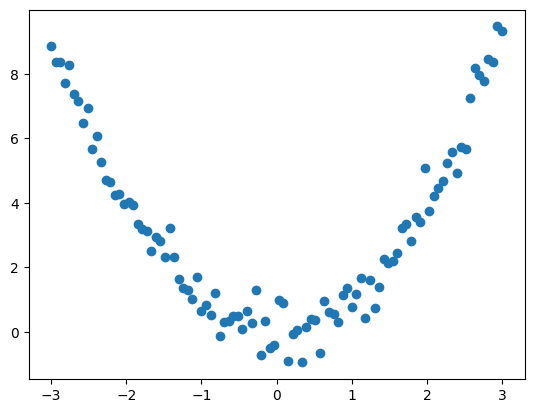

In [11]:
plt.scatter(df['x'], df['y'])

In [13]:
X, y = df[['x']], df['y']

# 🏗️ ১. আন্ডারফিট মডেল (Degree = 1) - High Bias
model_low = LinearRegression().fit(X, y)

# 🏗️ ২. পারফেক্ট ব্যালেন্সড মডেল (Degree = 2) - Sweet Spot
model_ideal = Pipeline([
    ('poly', PolynomialFeatures(degree=2)), 
    ('linear', LinearRegression())
]).fit(X, y)

# 🏗️ ৩. ওভারফিট মডেল (Degree = 15) - High Variance (ডাটা মুখস্থ করার চেষ্টা)
model_high = Pipeline([
    ('poly', PolynomialFeatures(degree=15)), 
    ('linear', LinearRegression())
]).fit(X, y)

## Checking biasness through training set

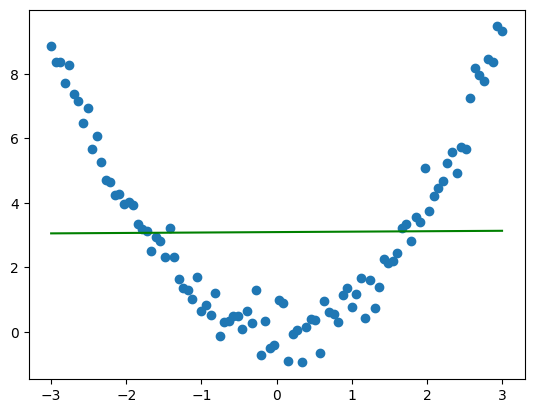

In [14]:
y_poly_pred= model_low.predict(X)
plt.scatter(X, y)
plt.plot(X, y_poly_pred, color="green")
plt.show()

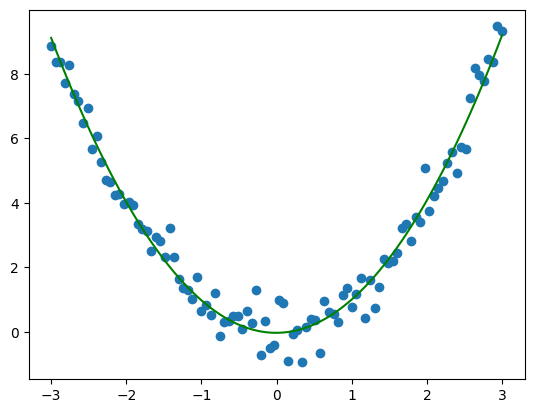

In [15]:
y_poly_pred= model_ideal.predict(X)
plt.scatter(X, y)
plt.plot(X, y_poly_pred, color="green")
plt.show()

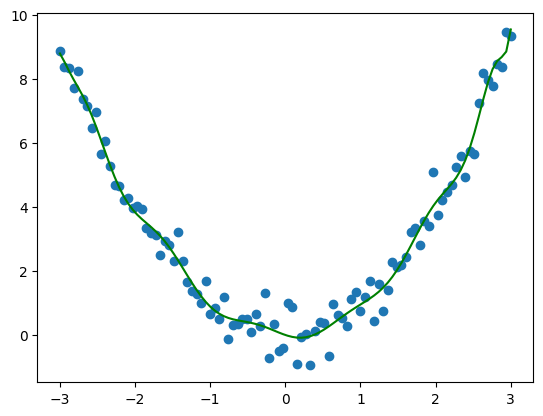

In [16]:
y_poly_pred= model_high.predict(X)
plt.scatter(X, y)
plt.plot(X, y_poly_pred, color="green")
plt.show()